In [25]:
import torch
import torch.nn as nn
import torch.optim as optim


##Architecture

In [26]:
class ANN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(ANN, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


In [27]:
input_size = 2      # x1 and x2
hidden_size = 8     # small hidden layer works well
output_size = 1    # binary output

model = ANN(input_size, hidden_size, output_size)



In [28]:
import numpy as np
import torch

# All XOR input combinations
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# XOR outputs
y = np.array([
    [0],
    [1],
    [1],
    [0]
])

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


##Loss Function & Optimizer

In [29]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


##Training

In [30]:
train_losses = []



import matplotlib.pyplot as plt

num_epochs = 100
train_losses = []

for epoch in range(num_epochs):

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


Epoch [10/100], Loss: 0.6042
Epoch [20/100], Loss: 0.5669
Epoch [30/100], Loss: 0.5320
Epoch [40/100], Loss: 0.4998
Epoch [50/100], Loss: 0.4700
Epoch [60/100], Loss: 0.4424
Epoch [70/100], Loss: 0.4167
Epoch [80/100], Loss: 0.3927
Epoch [90/100], Loss: 0.3703
Epoch [100/100], Loss: 0.3493


In [31]:
with torch.no_grad():
    predictions = model(X_test)


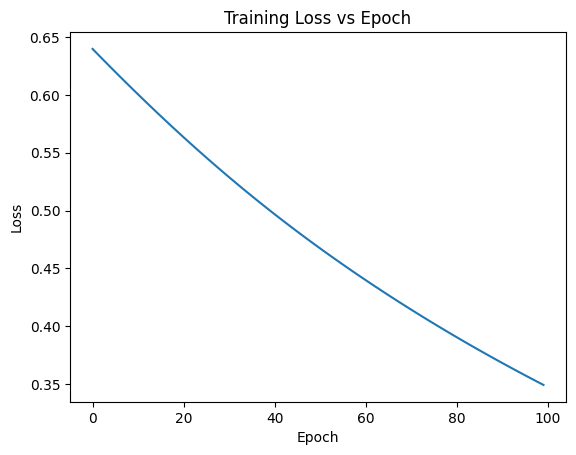

In [32]:
plt.figure()
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")
plt.show()
